In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.time import Time
import glob

In [3]:
from gammapy.data import Observation, Observations
from astropy.coordinates import SkyCoord, Angle
from regions import  PointSkyRegion, CircleSkyRegion

In [4]:
def get_rad_max(energy,energy_low,energy_high,rad_max):
    
    w = np.where( ( energy>= energy_low) * ( energy <= energy_high) )[0][0]
    return rad_max[w]

def get_On_Off_condition( observation):
    ra_obj     = observation.obs_info['RA_OBJ']
    dec_obj    = observation.obs_info['DEC_OBJ']
    source_pos =  SkyCoord( ra=ra_obj *u.deg,   dec=dec_obj *u.deg )
    
    pointing_pos = observation.pointing_radec
    
    offset       = source_pos.separation(pointing_pos)
    source_angle = pointing_pos.position_angle(source_pos).to(u.degree)
    
    off1_angle   = source_angle + 90*u.deg
    off2_angle   = off1_angle   + 90*u.deg
    off3_angle   = off2_angle   + 90*u.deg
    
    off1_pos    = pointing_pos.directional_offset_by(position_angle=off1_angle, separation=offset)  
    off2_pos    = pointing_pos.directional_offset_by(position_angle=off2_angle, separation=offset)  
    off3_pos    = pointing_pos.directional_offset_by(position_angle=off3_angle, separation=offset) 
    
    energy_low  = np.array( observation.rad_max.to_table()['ENERG_LO'] ).flatten() *u.TeV
    energy_high = np.array( observation.rad_max.to_table()['ENERG_HI'] ).flatten() *u.TeV
    rad_max     = np.array( observation.rad_max.to_table()['RAD_MAX'] ).flatten() *u.deg
    
    cond_on  = []
    cond_off = []
    for position_event, energy_event in zip(observation.events.radec,observation.events.energy):
        radius = get_rad_max(energy_event,energy_low,energy_high,rad_max)
        
        cond_on.append( source_pos.separation(position_event) <= radius )
        
        cond_off1 = off1_pos.separation(position_event) <= radius 
        cond_off2 = off2_pos.separation(position_event) <= radius 
        cond_off3 = off3_pos.separation(position_event) <= radius 
        
        cond_off.append( cond_off1 +  cond_off2 + cond_off3)
        
    return cond_on, cond_off

In [5]:
class Events:
    def __init__(self,
                 energies,
                 times,
                 trigger_time
                ):
        '''
        Initialize the Events class with event energies, times, trigger time, and energy ranges.
        
        Parameters
        ----------
        energies : astropy.units.quantity.Quantity
            An array of event energies with energy units.
        times : astropy.units.quantity.Quantity
            An array of event times with time units, in MJD format.
        trigger_time : astropy.units.quantity.Quantity
            The time of the trigger with time units, in MJD format.
        emin : astropy.units.quantity.Quantity
            The lower energy limit with energy units.
        emax : astropy.units.quantity.Quantity
            The upper energy limit with energy units.
        '''

        self.energies     = energies
        self.times        = times
        self.trigger_time = trigger_time

        # Shift the times by the trigger time and convert to seconds
        self.times = (self.times - self.trigger_time).to(u.s)



    def select_events(self, tmin=None, tmax=None, emin=None,emax=None):
        '''
        Select events within a given time range.
        
        Parameters
        ----------
        tmin : astropy.units.quantity.Quantity
            The lower time limit with time units.
        tmax : astropy.units.quantity.Quantity
            The upper time limit with time units.
        '''
        
        if tmin is None:
            tmin = -np.inf *u.s
        if tmax is None:
            tmax = np.inf *u.s
          
        if emin is None:
            emin = -np.inf *u.GeV
        if emax is None:
            emax = np.inf *u.GeV
        

        time_cond = (self.times > tmin) * (self.times < tmax)
        ener_cond = (self.energies > emin) * (self.energies < emax)
        cond           = time_cond*ener_cond
        self.times     = self.times[cond]
        self.energies  = self.energies[cond]


    def get_counts(self, timeedges, energyedges):
        '''
        Get the number events in each time and energy bin
        
        Parameters
        ----------
        timeedges : astropy.units.quantity.Quantity
            An array of time bin edges with time units.
        energyedges : astropy.units.quantity.Quantity
            An array of energy bin edges with energy units.
        '''

        self.t_left  = timeedges[:-1]
        self.t_right = timeedges[1:]
        
        self.e_left  = energyedges[:-1]
        self.e_right = energyedges[1:]

        self.n                   = []
        
        for t1, t2 in zip(self.t_left, self.t_right):
            n2 = []
            for e1, e2 in zip(self.e_left, self.e_right):
                # Get counts per time and energy bin at HE
                condition_t = (self.times >= t1) * (self.times <= t2)
                condition_e = (self.energies >= e1) * (self.energies <= e2)
                condition   = condition_t*condition_e
                n2.append(np.sum(condition))
            self.n.append(n2)
            
        self.n = np.array(self.n)

In [6]:
all_obs = []
for run in sorted(glob.glob( "./DL3_files/20*fits")):
    print(run)
    obs = Observation.read(run)
    all_obs.append(obs)

./DL3_files/20140426_05034767_DL3_Mrk421-W0.40+090.fits


'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.


./DL3_files/20140426_05034768_DL3_Mrk421-W0.40+270.fits
./DL3_files/20140426_05034771_DL3_Mrk421-W0.40+270.fits


'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.


./DL3_files/20140426_05034772_DL3_Mrk421-W0.40+000.fits
./DL3_files/20140426_05034773_DL3_Mrk421-W0.40+180.fits


'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.


./DL3_files/20140426_05034774_DL3_Mrk421-W0.40+090.fits
./DL3_files/20140426_05034775_DL3_Mrk421-W0.40+270.fits


'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.


./DL3_files/20140426_05034776_DL3_Mrk421-W0.40+000.fits
./DL3_files/20140426_05034777_DL3_Mrk421-W0.40+180.fits


'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.


# We get all times and energies for all events in the ON and OFF region for all Observations
### this might take a few minutes

In [7]:
%%time 

all_times_ON = np.array([])
all_energies_ON = np.array([])

all_times_OFF = np.array([])
all_energies_OFF = np.array([])

for obs in all_obs:
    
    cond_on, cond_off = get_On_Off_condition(obs)
    
    times        = obs.events.time.value
    energies     = obs.events.energy.to(u.GeV).value
    
    all_times_ON    = np.append( all_times_ON,times[cond_on] )
    all_energies_ON = np.append( all_energies_ON, energies[cond_on] )
    
    all_times_OFF    = np.append( all_times_OFF,times[cond_off] )
    all_energies_OFF = np.append( all_energies_OFF, energies[cond_off] )
    
    
all_times_ON    = Time( all_times_ON, format=obs.events.time.format)
all_energies_ON = all_energies_ON*u.GeV

all_times_OFF    = Time( all_times_OFF, format=obs.events.time.format)
all_energies_OFF = all_energies_OFF*u.GeV

/home/ddore/miniconda3/envs/damspi/lib/python3.9/site-packages/gammapy/data/observations.py:357: GammapyDeprecationWarning: obs_info property is deprecated since v1.2. Use meta instead.
  warnings.warn(


AttributeError: 'Observation' object has no attribute 'pointing_radec'

In [12]:
time_ref = all_obs[0].gti.time_start
time_ref

<Time object: scale='utc' format='mjd' value=[56772.93511676]>

In [13]:
t_start = []
t_stop = []
for obs in all_obs:
    t_start.append( (obs.gti.time_start - time_ref).to(u.s).value)
    t_stop.append( (obs.gti.time_stop - time_ref).to(u.s).value)
    
t_start = np.array(t_start).flatten()*u.s
t_stop  = np.array(t_stop).flatten()*u.s 

In [14]:
emin    = 100*u.GeV
emax    = 10*u.TeV

tmin    = t_start.min()
tmax    = t_stop.max()

In [17]:
# ON EVENTS
ON_events = Events( energies     = all_energies_ON,#np.random.choice(eee.to(u.GeV).value,len(eee))*u.GeV, 
                    times        = all_times_ON,#[all_energies_ON>emin],
                    trigger_time = time_ref,
                
                  )



ON_events.select_events( emin=emin,emax=emax,tmin=tmin, tmax=tmax)


# OFF EVENTS

OFF_events = Events( energies     = all_energies_OFF,
                    times        = all_times_OFF,
                    trigger_time = time_ref,

                  )

OFF_events.select_events( emin=emin,emax=emax,)

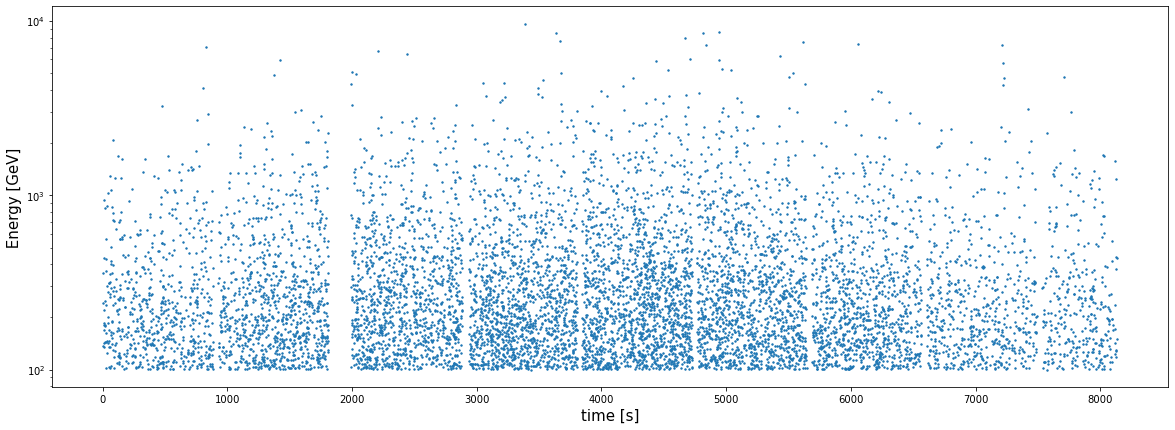

In [19]:
fig, ax = plt.subplots( 1,1,figsize=(20,7))

ax.set_ylabel(r' Energy [GeV] ',size=15)
ax.set_xlabel('time [s]',size=15)

ax.scatter( ON_events.times,  ON_events.energies, s=2)


ax.set_yscale('log')

In [20]:
# This binning in unifor: only bins ghave same size
# In principle one can try different bins, indeed in the paper we studied how the resul change by using different binning|
t_prime_left  = np.array([0, 118.25297, 236.50594, 354.7589, 473.01187, 591.26484, 709.51781, 827.77078, 946.02374, 1064.2767, 
          1182.5297, 1300.7826, 1419.0356, 1537.2886, 1655.5416, 1773.7945, 1892.0475, 2010.3005, 2128.5534, 
          2246.8064, 2365.0594, 2483.3123, 2601.5653, 2719.8183, 2838.0712, 2956.3242, 3074.5772, 3192.8301, 
          3311.0831, 3429.3361, 3547.589, 3665.842, 3784.095, 3902.3479, 4020.6009, 4138.8539, 4257.1068, 
          4375.3598, 4493.6128, 4611.8657, 4730.1187, 4848.3717, 4966.6247, 5084.8776, 5203.1306, 5321.3836, 
          5439.6365, 5557.8895, 5676.1425, 5794.3954, 5912.6484, 6030.9014, 6149.1543, 6267.4073, 6385.6603, 
          6503.9132, 6622.1662, 6740.4192, 6858.6721, 6976.9251, 7095.1781, 7213.431, 7331.684, 7449.937, 7568.1899, 
          7686.4429, 7804.6959, 7922.9489, 8041.2018])*u.s

t_prime_right = np.array( [ 118.25297, 236.50594, 354.7589, 473.01187, 591.26484, 709.51781, 827.77078, 946.02374, 1064.2767,
                       1182.5297, 1300.7826, 1419.0356, 1537.2886, 1655.5416, 1773.7945, 1892.0475, 2010.3005, 2128.5534,
                       2246.8064, 2365.0594, 2483.3123, 2601.5653, 2719.8183, 2838.0712, 2956.3242, 3074.5772, 3192.8301,
                       3311.0831, 3429.3361, 3547.589, 3665.842, 3784.095, 3902.3479, 4020.6009, 4138.8539, 4257.1068, 
                       4375.3598, 4493.6128, 4611.8657, 4730.1187, 4848.3717, 4966.6247, 5084.8776, 5203.1306, 5321.3836,
                       5439.6365, 5557.8895, 5676.1425, 5794.3954, 5912.6484, 6030.9014, 6149.1543, 6267.4073, 6385.6603,
                       6503.9132, 6622.1662, 6740.4192, 6858.6721, 6976.9251, 7095.1781, 7213.431, 7331.684, 7449.937, 
                       7568.1899, 7686.4429, 7804.6959, 7922.9489, 8041.2018, 8159.4548])*u.s

t_prime = np.append( t_prime_left, t_prime_right[-1] ) 

        
    
# Binning in time
E_prime = np.geomspace(  100*u.GeV, 10*u.TeV, 11)

In [22]:
ON_events.get_counts(timeedges=t_prime, energyedges=E_prime)
OFF_events.get_counts(timeedges=t_prime, energyedges=E_prime)


<ErrorbarContainer object of 3 artists>

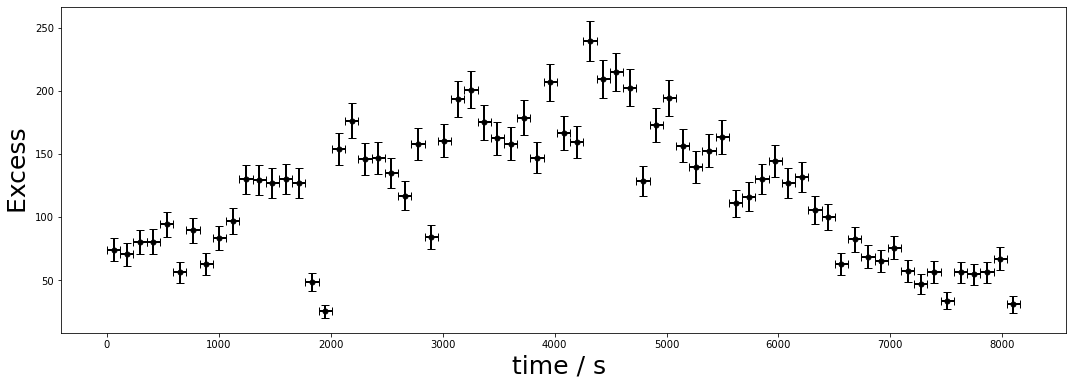

In [24]:

binwidth       = t_prime[1:]-t_prime[:-1]
bincenters     = (t_prime[1:]+t_prime[:-1])/2
LC_intr        = (ON_events.n.sum(axis=1) - OFF_events.n.sum(axis=1)/3) 
LC_intr_unc    = np.sqrt( (ON_events.n.sum(axis=1) + OFF_events.n.sum(axis=1)*(1/3)**2) )

rel_unc_per_time_bin = LC_intr_unc/LC_intr
rel_unc_per_time_bin[np.isnan(rel_unc_per_time_bin)] = 0

fig, ax = plt.subplots( 1,1,figsize=(18,6))

#ax.set_ylabel(r' rate $\cdot$  s ',fontsize=25)
ax.set_ylabel(r' Excess ',fontsize=25)
ax.set_xlabel('time / s ',fontsize=25)



ax.errorbar(bincenters.value, LC_intr, LC_intr_unc ,binwidth.value/2,fmt='o', elinewidth=2, markersize=5, capsize=4,c='k')
